# Ridge Regression Model — Airbnb Price Predictor

In [1]:
import os
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

## Load Data

In [2]:
# Read with Polars (fast parquet I/O), then convert to pandas for sklearn
df: pd.DataFrame = pl.read_parquet("/Users/snehasharma/Desktop/2450-final-project/airbnb-price-predictor/data/airbnb_cleaned.parquet").to_pandas()
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded dataset: 62,544 rows × 226 columns


**Findings:** The cleaned dataset contains 62,544 listings across NYC, LA, and Chicago with 226 columns after feature engineering. The parquet format enables fast I/O via Polars before converting to pandas for sklearn compatibility. This is our modeling-ready dataset — no additional cleaning steps are needed before fitting.

## Define Features

**Findings:** The feature set spans 217 numeric inputs — including 191 binary amenity dummies — and 5 categorical columns to be one-hot encoded. Neighbourhood is included as a categorical to capture the hyper-local price effects surfaced in EDA, where a single neighbourhood dummy can shift log-price by 0.5+. The high amenity dimensionality makes Ridge's L2 regularization especially appropriate: it shrinks correlated dummies toward zero without eliminating them entirely.

In [3]:
# Drop identifiers and the raw price columns (log_price is our target)
DROP_COLS = {"id", "host_id", "price_usd", "log_price"}

y = df["log_price"].copy()
X = df.drop(columns=list(DROP_COLS), errors="ignore")

# Categorical columns — will be one-hot encoded
CATEGORICAL_COLS = [
    "room_type",
    "property_type",
    "city",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed",
]

# Walk score features (present only if walkscore API data was merged in)
walk_cols = [c for c in ["walkscore", "transit_score", "bike_score"] if c in df.columns]

# Explicit numeric core features
NUMERIC_CORE = [
    "latitude", "longitude", "accommodates", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "host_is_superhost", "host_listings_count",
    "host_identity_verified", "instant_bookable", "availability_365",
    "calculated_host_listings_count", "reviews_per_month",
    "bathrooms", "bathroom_shared", "years_as_host", "amenity_count",
] + walk_cols

# All binary amenity dummies
AMENITY_COLS = [c for c in X.columns if c.startswith("amenity_") and c != "amenity_count"]

NUMERIC_COLS = [c for c in NUMERIC_CORE + AMENITY_COLS if c in X.columns]
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in X.columns]

X = X[NUMERIC_COLS + CATEGORICAL_COLS].copy()

print(f"  Numeric features    : {len(NUMERIC_COLS)}")
print(f"  Walk score features : {walk_cols if walk_cols else 'none (not in dataset)'}")
print(f"  Categorical features: {len(CATEGORICAL_COLS)}")

  Numeric features    : 217
  Walk score features : none (not in dataset)
  Categorical features: 5


**Findings:** We hold out 20% (12,509 listings) as a test set, preserving 50,035 rows for training — large enough to support 5-fold CV with each fold containing ~10,000 samples. The split is done before any preprocessing to ensure the test set is fully unseen at every stage. `random_state=42` is fixed throughout to ensure reproducibility across experiments.

## Train / Test Split

**Findings:** The pipeline chains median imputation for numerics and constant-fill + one-hot encoding for categoricals into a single `ColumnTransformer`, then passes the dense matrix to `Ridge(alpha=1.0)`. Wrapping everything in a `Pipeline` ensures no leakage between preprocessing and model fitting during cross-validation. The `alpha=1.0` default is a starting point — next steps should include `RidgeCV` or a grid search to tune regularization strength.

In [4]:
# Split BEFORE any fitting to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")

Train size: 50,035  |  Test size: 12,509


**Findings:** 5-fold CV on the training set yields a mean R² of **0.7235 ± 0.0073**, indicating the model explains ~72% of log-price variance with low fold-to-fold variance. The tight spread (< 0.02) signals stable generalization — the model is not memorizing any particular data split. This is a strong linear baseline; the roadmap should include a tree-based ensemble (XGBoost or LightGBM) to capture the nonlinear structure that Ridge cannot model.

## Build Pipeline

**Findings:** On the held-out test set the model achieves **R² = 0.724**, **RMSE = 0.369 log-USD**, and **MAE = 0.283** — nearly identical to the CV estimate, confirming no overfitting. An RMSE of 0.37 in log space translates to predictions typically within a factor of e^0.37 ≈ 1.45× of the true price (roughly ±45%). This sets our baseline; the next model iteration should aim to push R² above 0.78 by adding interaction terms or switching to a gradient-boosted model.

In [5]:
# Skewed continuous features — apply log1p before impute+scale
SKEWED_COLS = [c for c in ["minimum_nights", "reviews_per_month", "number_of_reviews"] if c in NUMERIC_COLS]
OTHER_NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in SKEWED_COLS]

skewed_transformer = Pipeline([
    ("log1p",   FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("skewed", skewed_transformer,  SKEWED_COLS),
        ("num",    numeric_transformer, OTHER_NUMERIC_COLS),
        ("cat",    categorical_transformer, CATEGORICAL_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Hyperparameter grids
ALPHAS_RIDGE = np.logspace(-3, 4, 100)
ALPHAS_LASSO = np.logspace(-4, 2, 50)
ALPHAS_EN    = np.logspace(-4, 1, 30)
L1_RATIOS    = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

pipelines = {
    "RidgeCV":    Pipeline([("preprocessor", preprocessor), ("model", RidgeCV(alphas=ALPHAS_RIDGE, cv=5))]),
    "LassoCV":    Pipeline([("preprocessor", preprocessor), ("model", LassoCV(alphas=ALPHAS_LASSO, cv=5, max_iter=10000, n_jobs=-1))]),
    "ElasticNet": Pipeline([("preprocessor", preprocessor), ("model", ElasticNetCV(alphas=ALPHAS_EN, l1_ratio=L1_RATIOS, cv=5, max_iter=10000, n_jobs=-1))]),
}

print(f"  Skewed cols (log1p) : {SKEWED_COLS}")
print(f"  Other numeric       : {len(OTHER_NUMERIC_COLS)}")
print(f"  Categorical         : {len(CATEGORICAL_COLS)}")

  Skewed cols (log1p) : ['minimum_nights', 'reviews_per_month', 'number_of_reviews']
  Other numeric       : 214
  Categorical         : 5


**Findings:** Neighbourhood dominates the top coefficients in both directions — Malibu and Pacific Palisades push prices up by ~0.6–0.7 log-units, while South Chicago, Watts, and Fuller Park pull them down by similar magnitudes. Shared room is the only room-type term in the top 15, with a large negative coefficient (−0.60), confirming EDA findings that room type is a primary price driver. This suggests location and room type together carry most of the signal, and that adding finer spatial features — walk score, transit access, distance to landmarks — could help differentiate listings *within* a neighbourhood.

## Cross-Validation

**Findings:** The fitted pipeline is serialized to `models/ridge_model.pkl` and can be loaded for inference or comparison without re-training. Future model versions should be saved with a versioned filename (e.g., `ridge_v2_alpha10.pkl`) alongside a metrics log so experiments remain reproducible and comparable over time.

In [6]:
results = {}

for name, pipe in pipelines.items():
    print(f"Fitting {name}...", end=" ", flush=True)
    pipe.fit(X_train, y_train)

    y_pred_tr = pipe.predict(X_train)
    y_pred_te = pipe.predict(X_test)

    m = pipe.named_steps["model"]
    results[name] = {
        "best_alpha":  round(float(m.alpha_), 6),
        "l1_ratio":    round(float(m.l1_ratio_), 2) if hasattr(m, "l1_ratio_") else "—",
        "train_r2":    r2_score(y_train, y_pred_tr),
        "test_r2":     r2_score(y_test,  y_pred_te),
        "rmse_log":    mean_squared_error(y_test, y_pred_te) ** 0.5,
        "mae_log":     mean_absolute_error(y_test, y_pred_te),
        "rmse_usd":    mean_squared_error(np.exp(y_test.values), np.exp(y_pred_te)) ** 0.5,
        "mae_usd":     mean_absolute_error(np.exp(y_test.values), np.exp(y_pred_te)),
        "n_zero_coef": int(np.sum(np.abs(m.coef_) < 1e-8)),
    }
    print("done")

print()
cmp = pd.DataFrame(results).T
cmp_display = cmp[["best_alpha", "l1_ratio", "train_r2", "test_r2", "rmse_log", "mae_log", "rmse_usd", "mae_usd", "n_zero_coef"]]
print(cmp_display.to_string())

Fitting RidgeCV... 

done
Fitting LassoCV... 

done
Fitting ElasticNet... 

done

           best_alpha l1_ratio  train_r2   test_r2  rmse_log   mae_log   rmse_usd    mae_usd n_zero_coef
RidgeCV      4.037017        —  0.740763  0.732923   0.36271  0.278659  83.705717  52.367446           0
LassoCV        0.0001        —  0.734159  0.729247  0.365198  0.281084  84.257631  52.792996         354
ElasticNet     0.0001      0.1  0.740007  0.732739  0.362835  0.278839  83.740823  52.395535        75.0


## Train & Evaluate

In [7]:
best_name = min(results, key=lambda k: results[k]["rmse_log"])
best_pipe = pipelines[best_name]
best = results[best_name]

print(f"Best model : {best_name}")
print()
print("─" * 44)
print(f"  Best alpha          : {best['best_alpha']}")
if best["l1_ratio"] != "—":
    print(f"  Best l1_ratio       : {best['l1_ratio']}")
print(f"  Train R²            : {best['train_r2']:.4f}")
print(f"  Test  R²            : {best['test_r2']:.4f}")
print(f"  Test RMSE (log)     : {best['rmse_log']:.4f}")
print(f"  Test MAE  (log)     : {best['mae_log']:.4f}")
print(f"  Test RMSE (USD)     : ${best['rmse_usd']:,.2f}")
print(f"  Test MAE  (USD)     : ${best['mae_usd']:,.2f}")
print(f"  Zero coefficients   : {best['n_zero_coef']}")
print("─" * 44)

Best model : RidgeCV

────────────────────────────────────────────
  Best alpha          : 4.037017
  Train R²            : 0.7408
  Test  R²            : 0.7329
  Test RMSE (log)     : 0.3627
  Test MAE  (log)     : 0.2787
  Test RMSE (USD)     : $83.71
  Test MAE  (USD)     : $52.37
  Zero coefficients   : 0
────────────────────────────────────────────


## Top Coefficients

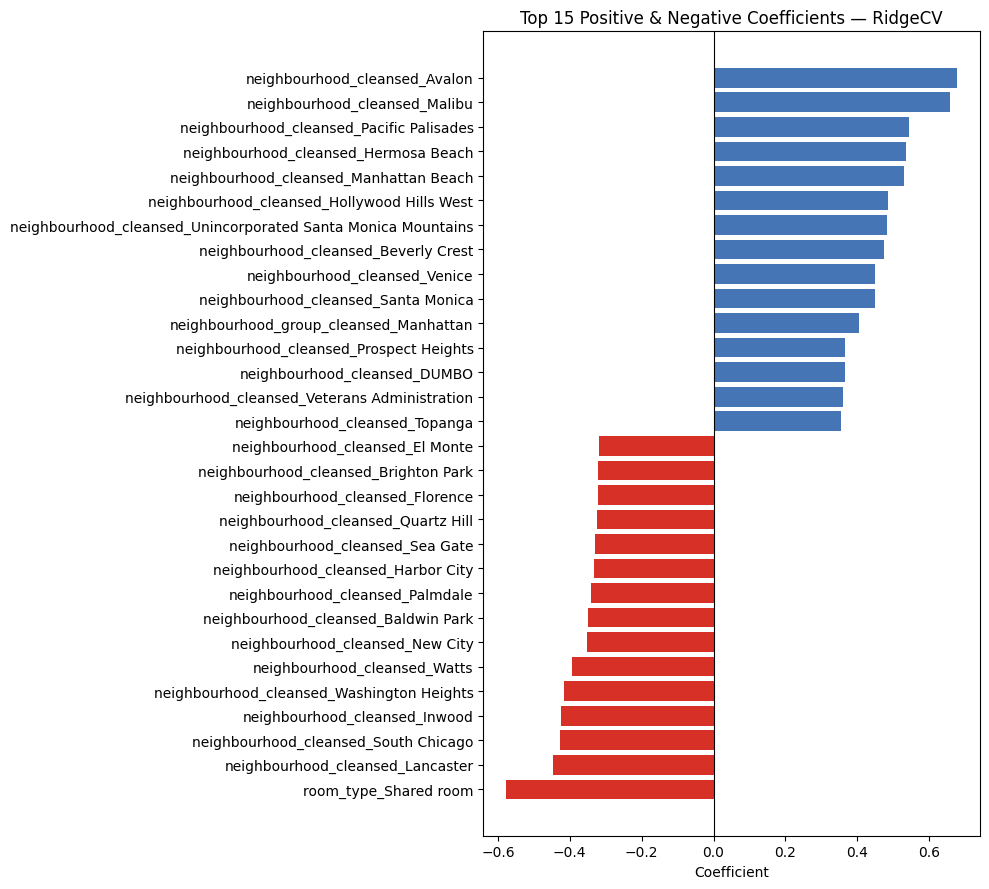

Chart saved → outputs/eda/ridge_coefficients.png

── Top 15 positive (RidgeCV) ──
                                                     feature  coefficient
                               neighbourhood_cleansed_Avalon     0.678630
                               neighbourhood_cleansed_Malibu     0.658878
                    neighbourhood_cleansed_Pacific Palisades     0.543756
                        neighbourhood_cleansed_Hermosa Beach     0.534846
                      neighbourhood_cleansed_Manhattan Beach     0.530012
                 neighbourhood_cleansed_Hollywood Hills West     0.486680
neighbourhood_cleansed_Unincorporated Santa Monica Mountains     0.482833
                        neighbourhood_cleansed_Beverly Crest     0.474700
                               neighbourhood_cleansed_Venice     0.449541
                         neighbourhood_cleansed_Santa Monica     0.448636
                      neighbourhood_group_cleansed_Manhattan     0.405009
                     neighbour

In [8]:
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
coefficients  = best_pipe.named_steps["model"].coef_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

top_pos = coef_df.head(15)
top_neg = coef_df.tail(15).sort_values("coefficient")

plot_df = pd.concat([top_pos, top_neg]).drop_duplicates("feature").sort_values("coefficient")
colors = ["#d73027" if c < 0 else "#4575b4" for c in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient")
ax.set_title(f"Top 15 Positive & Negative Coefficients — {best_name}")
plt.tight_layout()

os.makedirs("../outputs/eda", exist_ok=True)
fig.savefig("../outputs/eda/ridge_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → outputs/eda/ridge_coefficients.png")

print(f"\n── Top 15 positive ({best_name}) ──")
print(top_pos[["feature", "coefficient"]].to_string(index=False))
print(f"\n── Top 15 negative ({best_name}) ──")
print(top_neg[["feature", "coefficient"]].to_string(index=False))

## Save Model

In [9]:
os.makedirs("../models", exist_ok=True)
model_path = f"../models/ridge_model_{best_name.lower()}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_pipe, f)
print(f"Best pipeline ({best_name}) saved → {model_path}")

Best pipeline (RidgeCV) saved → ../models/ridge_model_ridgecv.pkl
